In [45]:
import numpy as np #biblioteca pentru manipularea array-ului si o redenumeste in np pentru a fi utilizata mai usor
import pandas as pd #biblioteca pentru manipularea si analiza datelor, precum DataFrame

import matplotlib.pyplot as plt #pentru crearea graficelor
from sklearn.datasets import fetch_california_housing #încarcă setul de date California Housing
from sklearn.ensemble import RandomForestRegressor #clasa pentru implementarea algoritmului Random Forest
#from sklearn.linear_model import LinearRegression #clasa pentru implementarea algoritmului de regresie liniară

from sklearn.model_selection import train_test_split #funcție pentru împărțirea datelor în seturi de antrenare și testare.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

In [46]:
data = fetch_california_housing()
X = data.data  # Features (e.g., median income, population, etc.)
y = data.target  # Target variable (median house value)

In [47]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
# Initialize and train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
#model = LinearRegression()

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [49]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [50]:
# Evaluate the model
mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)

print(f"Performance on Training Set:")
print(f" - MSE: {mse_train}")
print(f" - MAE: {mae_train}")
print(f" - R2 Score: {r2_train}")
print(f" - RMSE Score: {rmse_train}\n")

print(f"Performance on Test Set:")
print(f" - MSE: {mse_test}")
print(f" - MAE: {mae_test}")
print(f" - R2 Score: {r2_test}")
print(f" - RMSE Score: {rmse_test}\n")

Performance on Training Set:
 - MSE: 0.03531189000665492
 - MAE: 0.12205181251816899
 - R2 Score: 0.9735843315703163
 - RMSE Score: 0.18791458167650246

Performance on Test Set:
 - MSE: 0.255553781221915
 - MAE: 0.32761335695251953
 - R2 Score: 0.804981661858749
 - RMSE Score: 0.5055232746589567



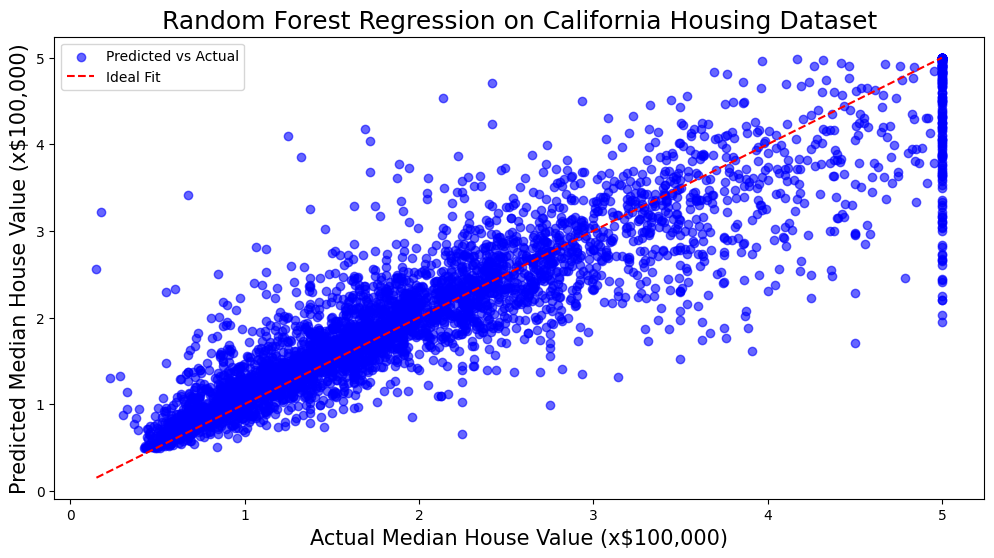

In [51]:
# Visualize predictions for the test set
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, color='blue', label='Predicted vs Actual')
plt.plot()
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Median House Value (x$100,000)', fontsize=15)
plt.ylabel('Predicted Median House Value (x$100,000)', fontsize=15)
plt.title('Random Forest Regression on California Housing Dataset', fontsize=18)
plt.legend()
plt.show()

In [52]:
feature_names = data.feature_names  # Names of the features
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Plot the actual vs. predicted values for each feature in the test set
plt.figure(figsize=(20, 40))
for i, feature in enumerate(feature_names):
    plt.subplot(4, 2, i + 1)  # Arrange plots in a grid of 4 rows and 2 columns
    plt.scatter(X_test_df[feature], y_test, alpha=0.6, color='blue', label='Actual Values')
    plt.scatter(X_test_df[feature], y_pred_test, alpha=0.6, color='red', label='Predicted Values')
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Median House Value (x$100,000)', fontsize=12)
    plt.title(f'Actual vs Predicted for {feature}', fontsize=15)
    plt.legend()

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.